## Part 2

In [ ]:
#Import needed libraries
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

#Sklearn imports, used for ML models and evaluation metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.neighbors import LocalOutlierFactor
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import make_scorer, mean_absolute_error
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [264]:
#Import dataset and preview
path = kagglehub.dataset_download(
    "uciml/red-wine-quality-cortez-et-al-2009"
)

df = pd.read_csv(f"{path}/winequality-red.csv")

#Preview the dataset and info about the columns and data types
print(df.head())
print(df.info())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [265]:
#Train/test/eval splits
train_reduced, test_df = train_test_split(df, test_size=0.15, random_state=42)
train_df, val_df = train_test_split(train_reduced, test_size=0.15, random_state=42)

print(f"Total samples:         {len(df)}")
print(f"Holdout test set:      {len(test_df)} ({len(test_df)/len(df):.0%})")
print(f"train_reduced:         {len(train_reduced)} ({len(train_reduced)/len(df):.0%})")
print(f"  Train:               {len(train_df)} ({len(train_df)/len(df):.0%})")
print(f"  Validation:          {len(val_df)} ({len(val_df)/len(df):.0%})")

Total samples:         1599
Holdout test set:      240 (15%)
train_reduced:         1359 (85%)
  Train:               1155 (72%)
  Validation:          204 (13%)


In [266]:
#Data cleaning

#1. Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

#2. Check for duplicates
num_duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {num_duplicates}")

#3. Out of Range Values
#Check for negative values in features that should be non-negative
non_negative_features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
                            'pH', 'sulphates', 'alcohol']
for feature in non_negative_features:
    num_negative = (df[feature] < 0).sum()
    if num_negative > 0:
        print(f"\nFeature '{feature}' has {num_negative} negative values.")
else:
    print("\nNo negative values found in non-negative features.")



Missing values in each column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Number of duplicate rows: 240

No negative values found in non-negative features.


In [267]:
#Clean duplicate rows
if num_duplicates > 0:
    df = df.drop_duplicates()
    print(f"Removed {num_duplicates} duplicate rows. New total: {len(df)}")

Removed 240 duplicate rows. New total: 1359


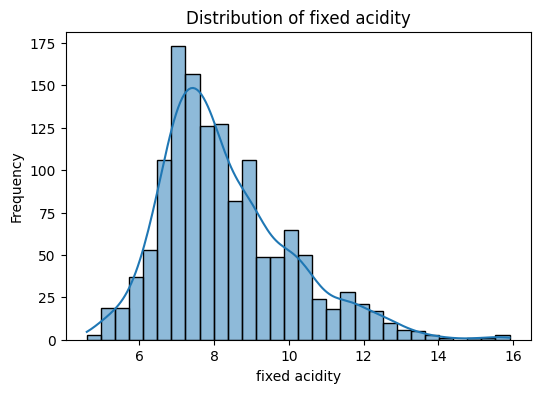

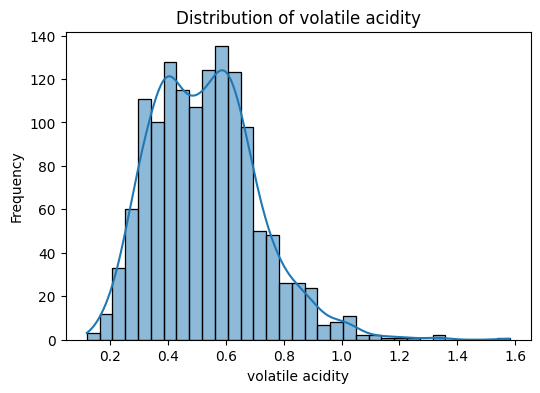

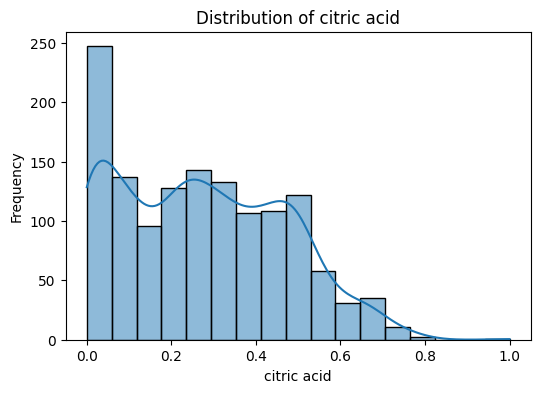

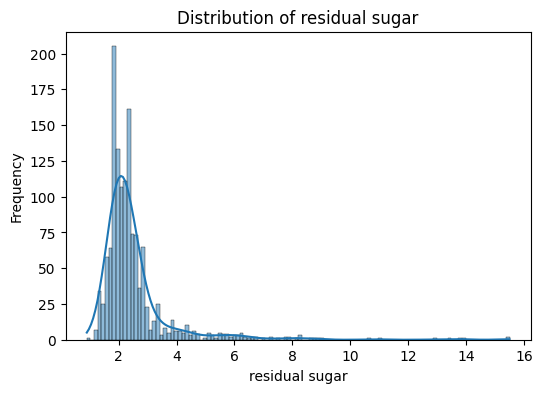

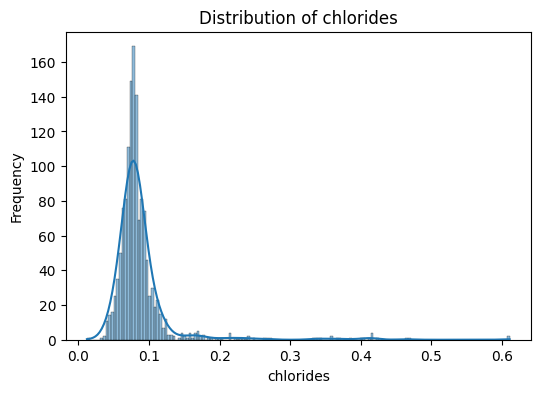

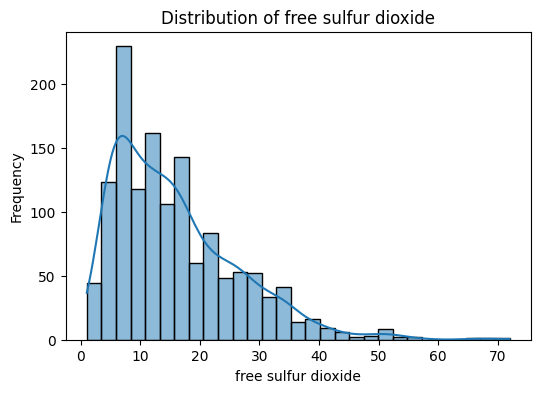

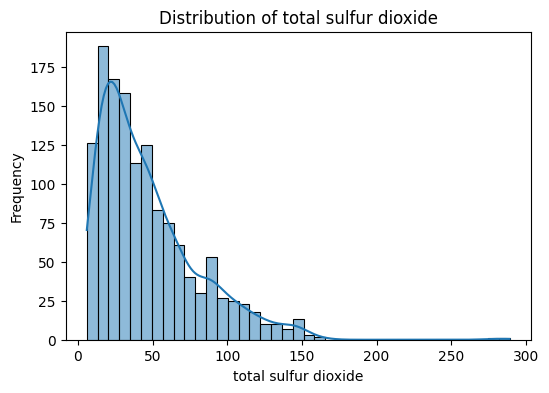

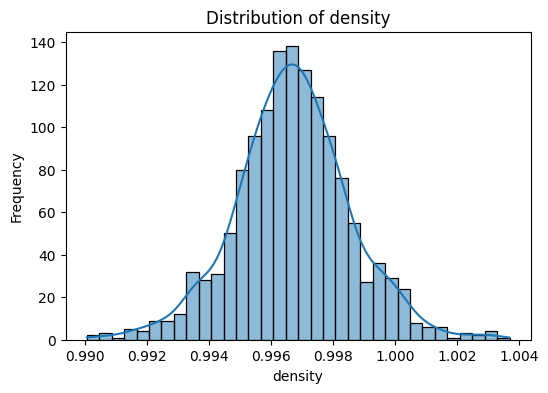

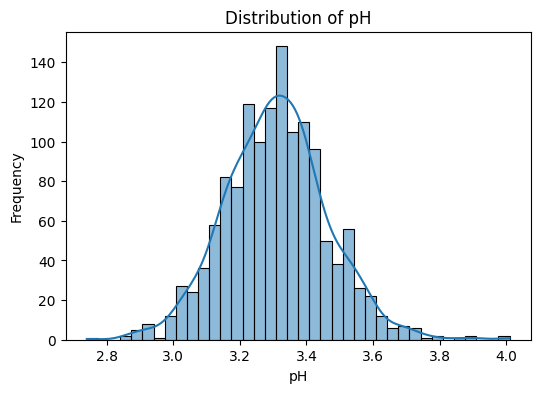

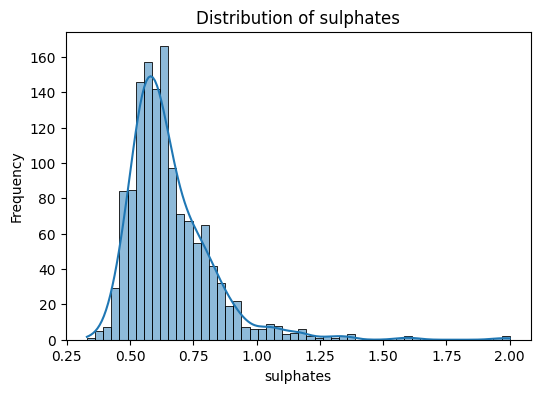

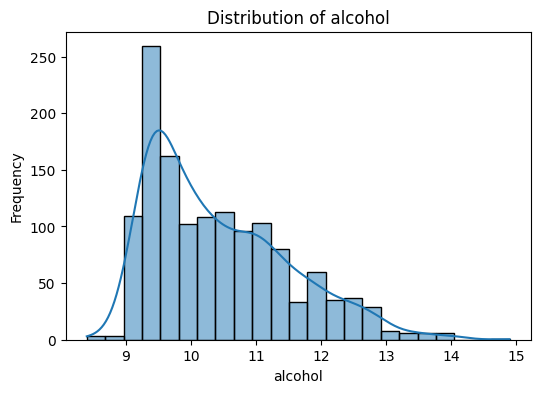

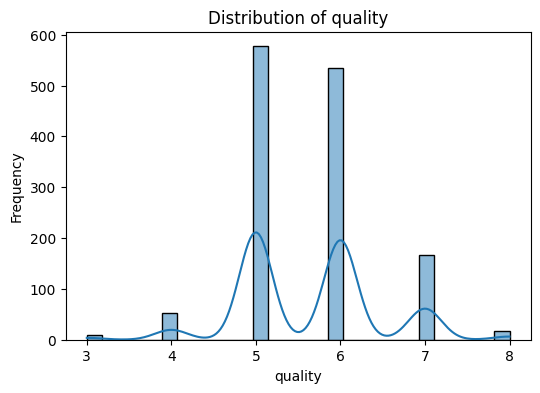

In [268]:
#Visualize distribution of all features
for col in df.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()



/Users/jonathanc/dev/school/Data_Science/DataScienceA2/.venv/lib/python3.9/site-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


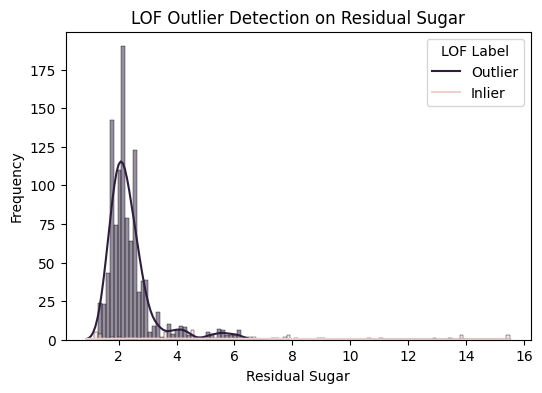

In [269]:
#Perform LOF to detect outliers in residual sugar

#First calculate mean for imputation
train_df_imputed = train_df.copy()
mean_residual_sugar = train_df_imputed['residual sugar'].mean()

#Perform LOF on residual sugar
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
train_df_imputed['lof_residual_sugar'] = lof.fit_predict(train_df_imputed[['residual sugar']].fillna(mean_residual_sugar))

#Visualize LOF results
plt.figure(figsize=(6, 4))
sns.histplot(data=train_df_imputed, x='residual sugar', kde=True, hue='lof_residual_sugar')
plt.title("LOF Outlier Detection on Residual Sugar")
plt.xlabel("Residual Sugar")
plt.ylabel("Frequency")
plt.legend(title='LOF Label', labels=['Outlier', 'Inlier'])
plt.show()

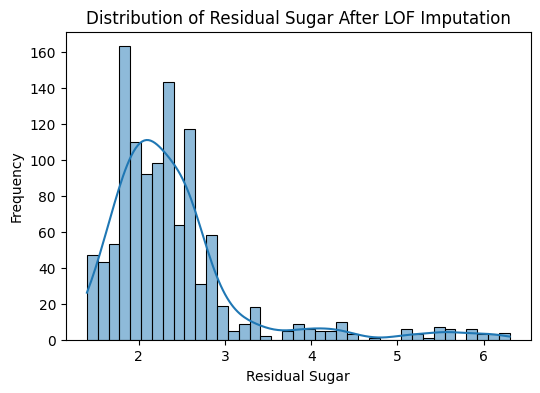

In [270]:
#Copy dataset and impute outliers with mean value
train_df_imputed.loc[train_df_imputed['lof_residual_sugar'] == -1, 'residual sugar'] = mean_residual_sugar

#Re-visualize distribution of residual sugar after imputation
plt.figure(figsize=(6, 4))
sns.histplot(train_df_imputed['residual sugar'], kde=True)
plt.title("Distribution of Residual Sugar After LOF Imputation")
plt.xlabel("Residual Sugar")
plt.ylabel("Frequency")
plt.show()

In [271]:
#Dataset with 2 aggregate features
#Total acidity = fixed acidity + volatile acidity, Chemical Balance = citric acid / (fixed acidity + volatile acidity)
train_df_imputed['total acidity'] = train_df_imputed['fixed acidity'] + train_df_imputed['volatile acidity']
train_df_imputed['chemical balance'] = train_df_imputed['citric acid'] / (train_df_imputed['fixed acidity'] + train_df_imputed['volatile acidity'])

In [272]:
#Cleaned dataset with binary quality binning: Poor=0 (1-5), Good=1 (6-10)
train_df_binned = train_df_imputed.copy()

def quality_bin(quality):
    if quality <= 5:
        return 0  # Poor
    else:
        return 1  # Good

train_df_binned['quality_bin'] = train_df_binned['quality'].apply(quality_bin)

In [273]:
#Apply same pipeline to val_df (using stats from train only)
val_df_imputed = val_df.copy()

#Apply same aggregate features
val_df_imputed['total acidity'] = val_df_imputed['fixed acidity'] + val_df_imputed['volatile acidity']
val_df_imputed['chemical balance'] = val_df_imputed['citric acid'] / (val_df_imputed['fixed acidity'] + val_df_imputed['volatile acidity'])

#Apply same ordinal quality binning (0=Low, 1=Medium, 2=High)
val_df_binned = val_df_imputed.copy()
val_df_binned['quality_bin'] = val_df_binned['quality'].apply(quality_bin)

Decision Tree Classifier on Uncleaned, un-imputed dataset
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.13      0.29      0.18         7
           5       0.53      0.87      0.66        77
           6       0.44      0.04      0.08        91
           7       0.24      0.45      0.32        22
           8       0.20      0.33      0.25         6

    accuracy                           0.42       204
   macro avg       0.26      0.33      0.25       204
weighted avg       0.44      0.42      0.33       204



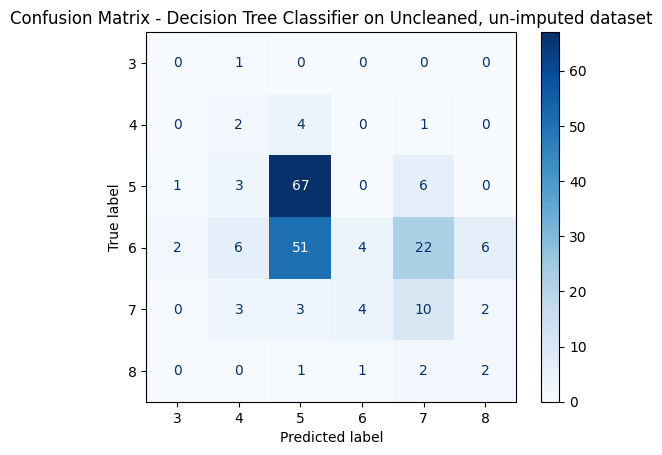

In [290]:
#Experiment 1: Decision Tree Classifier on Uncleaned, un-imputed dataset
#Define baseline DT model
dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

#Train Test
dt.fit(train_df.drop(columns=['quality']), train_df['quality'])
val_preds_dt = dt.predict(val_df.drop(columns=['quality']))

#Print evaluation metrics
print("Decision Tree Classifier on Uncleaned, un-imputed dataset")
print(classification_report(val_df['quality'], val_preds_dt))

#Confusion matrix
cm = confusion_matrix(val_df['quality'], val_preds_dt, labels=dt.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Decision Tree Classifier on Uncleaned, un-imputed dataset")
plt.show()



Decision Tree Classifier on cleaned, imputed and aggregate feature dataset
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.17      0.57      0.26         7
           5       0.67      0.73      0.70        77
           6       0.59      0.30      0.39        91
           7       0.30      0.55      0.39        22
           8       0.33      0.17      0.22         6

    accuracy                           0.49       204
   macro avg       0.34      0.38      0.33       204
weighted avg       0.56      0.49      0.50       204



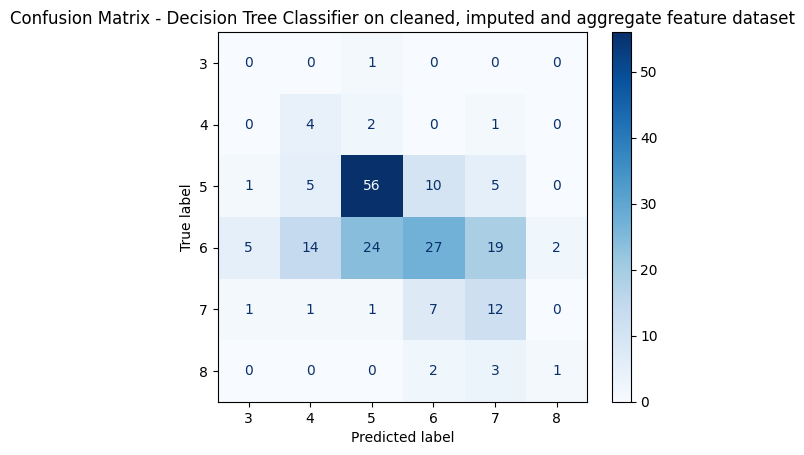

In [291]:
#Experiment 2: Decision Tree Classifier on cleaned, imputed and aggregate feature dataset
#Also experiment with tweaked parameters
dt_cleaned = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)

#Exclude lof_residual_sugar — it's a cleaning artifact, not a predictive feature
drop_cols = ['quality', 'lof_residual_sugar']
train_features = train_df_imputed.drop(columns=drop_cols)
val_features = val_df_imputed.drop(columns=['quality'])

#Train and predict
dt_cleaned.fit(train_features, train_df_imputed['quality'])
val_preds_dt_cleaned = dt_cleaned.predict(val_features)

#Print evaluation metrics
print("Decision Tree Classifier on cleaned, imputed and aggregate feature dataset")
print(classification_report(val_df_imputed['quality'], val_preds_dt_cleaned))

#Confusion matrix
cm_cleaned = confusion_matrix(val_df_imputed['quality'], val_preds_dt_cleaned, labels=dt_cleaned.classes_)
disp_cleaned = ConfusionMatrixDisplay(confusion_matrix=cm_cleaned, display_labels=dt_cleaned.classes_)
disp_cleaned.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Decision Tree Classifier on cleaned, imputed and aggregate feature dataset")
plt.show()

Experiment 3 - 4-Fold CV MAE: 0.276 ± 0.017
(MAE of 0=perfect, 1=completely wrong)

Decision Tree — Binary Quality Binning (0=Poor, 1=Good)
              precision    recall  f1-score   support

        Poor       0.63      0.81      0.71        85
        Good       0.83      0.66      0.73       119

    accuracy                           0.72       204
   macro avg       0.73      0.73      0.72       204
weighted avg       0.75      0.72      0.72       204

Val MAE: 0.279


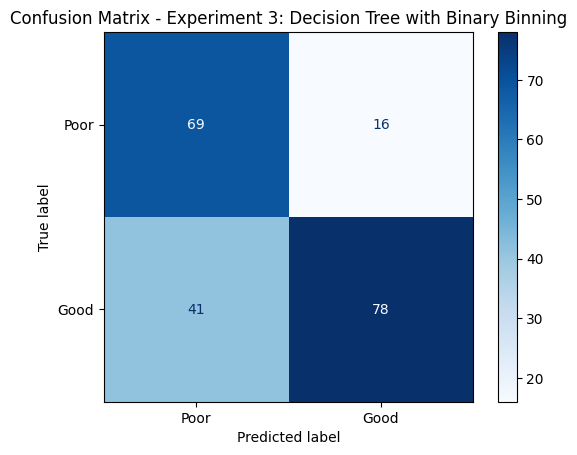

In [294]:
#Experiment 3: Decision Tree Classifier with binary quality binning (0=Poor, 1=Good)
dt_binned = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

feature_cols = [c for c in val_df_binned.columns if c not in ['quality', 'quality_bin']]

#Build train_reduced_binned for CV

X3 = train_df_binned[feature_cols]
y3 = train_df_binned['quality_bin']

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

cv_scores_3 = cross_val_score(dt_binned, X3, y3, cv=cv, scoring=mae_scorer)
print(f"Experiment 3 - 4-Fold CV MAE: {-cv_scores_3.mean():.3f} ± {cv_scores_3.std():.3f}")
print("(MAE of 0=perfect, 1=completely wrong)")

#Train on train_df_binned, evaluate on val_df_binned
dt_binned.fit(train_df_binned[feature_cols], train_df_binned['quality_bin'])
val_preds_dt_binned = dt_binned.predict(val_df_binned[feature_cols])

print("\nDecision Tree — Binary Quality Binning (0=Poor, 1=Good)")
print(classification_report(val_df_binned['quality_bin'], val_preds_dt_binned, target_names=['Poor', 'Good']))
print(f"Val MAE: {mean_absolute_error(val_df_binned['quality_bin'], val_preds_dt_binned):.3f}")

cm_binned = confusion_matrix(val_df_binned['quality_bin'], val_preds_dt_binned)
ConfusionMatrixDisplay(confusion_matrix=cm_binned, display_labels=['Poor', 'Good']).plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Experiment 3: Decision Tree with Binary Binning")
plt.show()

Experiment 4 - 4-Fold CV MAE: 0.233 ± 0.020
(MAE of 0=perfect, 1=completely wrong)

Random Forest — Binary Quality Binning (0=Poor, 1=Good)
              precision    recall  f1-score   support

        Poor       0.71      0.85      0.77        85
        Good       0.87      0.76      0.81       119

    accuracy                           0.79       204
   macro avg       0.79      0.80      0.79       204
weighted avg       0.81      0.79      0.80       204

Val MAE: 0.206


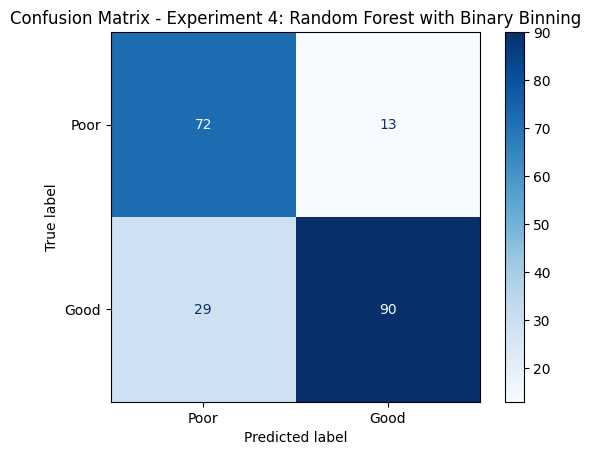

In [ ]:
#Experiment 4: Random Forest Classifier with binary quality binning (0=Poor, 1=Good)
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

feature_cols = [c for c in val_df_binned.columns if c not in ['quality', 'quality_bin']]


X_rf = train_df_binned[feature_cols]
y_rf = train_df_binned['quality_bin']

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

cv_scores_rf = cross_val_score(rf, X_rf, y_rf, cv=cv, scoring=mae_scorer)
print(f"Experiment 4 - 4-Fold CV MAE: {-cv_scores_rf.mean():.3f} ± {cv_scores_rf.std():.3f}")
print("(MAE of 0=perfect, 1=completely wrong)")

rf.fit(train_df_binned[feature_cols], train_df_binned['quality_bin'])
val_preds_rf = rf.predict(val_df_binned[feature_cols])

print("\nRandom Forest — Binary Quality Binning (0=Poor, 1=Good)")
print(classification_report(val_df_binned['quality_bin'], val_preds_rf, target_names=['Poor', 'Good']))
print(f"Val MAE: {mean_absolute_error(val_df_binned['quality_bin'], val_preds_rf):.3f}")

cm_rf = confusion_matrix(val_df_binned['quality_bin'], val_preds_rf)
ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Poor', 'Good']).plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Experiment 4: Random Forest with Binary Binning")
plt.show()